In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('final_chess.csv',index_col =[0])
df

C:\Users\miche\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
1,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
2,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
3,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
4,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
...,...,...,...,...,...,...,...
3691276,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3691277,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3691278,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3691279,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


In [6]:
df = df[df['MOVES'].notna()]
df.reset_index(drop=True)


,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
1,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
2,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
3,"Solomon, Stephen J","Sarapu, Ortvin",0-1,0021.01.21,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",NaN,2461.0
4,"Heinemann, T..","Krauss, Jo",1/2-1/2,0031.12.29,"['e4', 'd6', 'd4', 'Nf6', 'Nc3', 'g6', 'Be3', ...",2154.0,2320.0
...,...,...,...,...,...,...,...
3687188,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3687189,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3687190,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3687191,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


In [10]:
df['RESULT'].unique()

array(['*', '0-1', '1-0', '1/2-1/2'], dtype=object)

Getting all the matches ending with a victory

In [33]:
w_win = df[(df['RESULT'] == '1-0')]
w_win.reset_index(drop=True, inplace=True)
w_win

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
1,"Janetschek, Karl","Kormanyos, Zoltan",1-0,1792.??.??,"['e4', 'c5', 'Nf3', 'd6', 'd4', 'Nf6', 'Nc3', ...",2200.0,2450.0
2,"Hlavac, Frantisek","Djeno, Drago",1-0,1793.??.??,"['e4', 'c5', 'Nc3', 'Nc6', 'g3', 'g6', 'Bg2', ...",2185.0,2600.0
3,"Morphy, Paul","Harrwitz, Daniel",1-0,1837.??.??,"['e4', 'e5', 'Nf3', 'd6', 'd4', 'exd4', 'Qxd4'...",NaN,2590.0
4,"Morphy, Paul","Paulsen, Louis",1-0,1837.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",NaN,2590.0
...,...,...,...,...,...,...,...
1351280,"Qu, Yanqiao","Martini, Balazs",1-0,2010.07.07,"['e4', 'c5', 'Nf3', 'e6', 'd3', 'd6', 'g3', 'N...",2310.0,2069.0
1351281,"Kovalyov, Anton","Romanishin, Oleg M",1-0,2010.07.07,"['Nf3', 'd5', 'd4', 'Nf6', 'c4', 'dxc4', 'e3',...",2544.0,2487.0
1351282,"Kockum, A..","Olsson, Krister",1-0,2010.07.07,"['e4', 'd6', 'd4', 'Nf6', 'Nc3', 'g6', 'Bg5', ...",2338.0,2446.0
1351283,"Kotronias, Vasilios","Papadopoulos, Nikolaos1",1-0,2010.07.07,"['e4', 'c5', 'Nf3', 'd6', 'd4', 'cxd4', 'Nxd4'...",2105.0,2433.0


In [34]:
w_mov = w_win['MOVES'].to_list()

In [39]:
w_mov = [k.strip("[]").split(", ") for k in w_mov]   #change list of string to list of lists of strings

Getting number of wins by the white where a kingside castle or queenside castle took place respectively. 

In [84]:
w_king_cas = 0
w_queen_cas = 0

In [85]:
for i in w_mov:
    for j in i:
        if (j == "'O-O'") and ((i.index(j) %2) == 0):    #white moves have an even index
            w_king_cas += 1
        elif (j == "'O-O-O'") and ((i.index(j) %2) == 0):
            w_queen_cas +=1

In [86]:
w_king_cas

1105164

In [87]:
w_queen_cas

194585

Same process with black

In [71]:
b_win = df[(df['RESULT'] == '0-1')]
b_win.reset_index(drop=True, inplace=True)
b_win

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
1,"Solomon, Stephen J","Sarapu, Ortvin",0-1,0021.01.21,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",NaN,2461.0
2,"Morphy, Paul","Anderssen, Adolf",0-1,1818.??.??,"['e4', 'e5', 'Nf3', 'Nc6', 'Bc4', 'Bc5', 'b4',...",NaN,2670.0
3,"Anderssen, Adolf","Paulsen, Louis",0-1,1833.??.??,"['e4', 'e6', 'd4', 'd5', 'Nc3', 'Nf6', 'Bd3', ...",NaN,2594.0
4,"Bird, Henry","Steinitz, Wilhelm",0-1,1834.??.??,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",NaN,2594.0
...,...,...,...,...,...,...,...
1022688,"Lopez, Ri (wh)","Gaitan, Juan Manuel (bl)",0-1,2010.07.07,"['Nf3', 'd5', 'c4', 'd4', 'g3', 'Nc6', 'd3', '...",2047.0,2222.0
1022689,"Legrand, Stephane","Dionisi, Thomas",0-1,2010.07.07,"['d4', 'g6', 'c4', 'Bg7', 'Nc3', 'd6', 'Nf3', ...",2183.0,2557.0
1022690,"Chueca Forcen, Alberto","Cabrera, Ale",0-1,2010.07.07,"['d4', 'Nf6', 'c4', 'g6', 'Nc3', 'd5', 'Nf3', ...",2533.0,2112.0
1022691,"Kuchnio, Przemyslaw","Garbowska, Hanna",0-1,2010.07.07,"['e4', 'c5', 'Ne2', 'd6', 'g3', 'g6', 'Bg2', '...",2026.0,2395.0


In [77]:
b_mov = b_win['MOVES'].to_list()

In [78]:
b_mov = [k.strip("[]").split(", ") for k in b_mov]   #change list of string to list of lists of strings

In [88]:
b_king_cas = 0
b_queen_cas = 0

In [89]:
for i in b_mov:
    for j in i:
        if (j == "'O-O'") and ((i.index(j) %2) != 0):
            b_king_cas += 1
        elif (j == "'O-O-O'") and ((i.index(j) %2) != 0):
            b_queen_cas +=1

In [90]:
b_king_cas

746735

In [91]:
b_queen_cas

63766

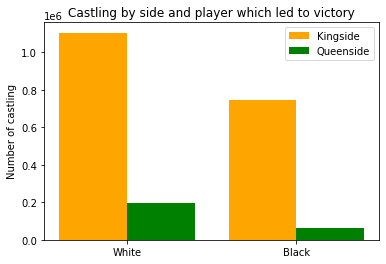

In [98]:
x = np.arange(2)
y1= [w_king_cas, b_king_cas]
y2=[w_queen_cas, b_queen_cas]
 
width = 0.4
  
# plot data in grouped manner of bar type
plt.bar(x-0.2, y1, width, color='orange')
plt.bar(x+0.2, y2, width, color='green')
plt.xticks(x, ['White', 'Black'])
plt.ylabel("Number of castling")
plt.legend(["Kingside", "Queenside"])
plt.title("Castling by side and player which led to victory")
plt.savefig('castle.png',dpi=300, bbox_inches = "tight")
plt.show()